# Qwen: распределение следующего токена и приближенного следующего слова

Этот ноутбук является улучшенной версией идеи из `qwen-distributions_v1.ipynb` и `qwen-distributions-v2.ipynb`.

Что он делает лучше:

- использует `Qwen/Qwen3-4B-Base`, как в `v2`, чтобы результат был сопоставим;
- берет небольшой, чистый и воспроизводимый датасет `ag_news`;
- считает распределение следующего токена по корпусу двумя способами: корректным `mean(softmax(logits))` и эвристическим `softmax(mean(logits))` из старого подхода;
- показывает, насколько эти способы отличаются;
- строит приближенное распределение следующего слова через BoW/word-start токены;
- выводит графики и короткие интерпретации;
- сохраняет PNG-графики и Markdown-отчет с результатами.

Важно: истинная вероятность следующего слова требует маргинализации по субсловным путям. Здесь word-level часть является практической BoW-аппроксимацией: мы агрегируем вероятности токенов, которые выглядят как начало следующего слова.

## Модуль 0: зависимости и среда

Ноутбук рассчитан на запуск в обычном Jupyter/Colab/локальной среде. Если пакеты отсутствуют, первая ячейка устанавливает их. Для локального запуска кэши HuggingFace, datasets, matplotlib и pip направляются внутрь папки `research`, чтобы не засорять корень репозитория.

In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "torch": "torch",
    "transformers": "transformers",
    "datasets": "datasets",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "accelerate": "accelerate",
    "tabulate": "tabulate",
}

missing = [pip_name for module_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module_name) is None]
if missing:
    print(f"Устанавливаю недостающие пакеты: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("Все необходимые пакеты уже установлены.")

Все необходимые пакеты уже установлены.


In [2]:
from __future__ import annotations

from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple
import json
import math
import os
import random
import re
import textwrap
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def resolve_research_dir() -> Path:
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "research":
        return cwd
    candidate = cwd / "research"
    if candidate.exists():
        return candidate.resolve()
    raise RuntimeError("Запускайте ноутбук из корня репозитория или из папки research.")


RESEARCH_DIR = resolve_research_dir()
ASSET_DIR = RESEARCH_DIR / "qwen_next_token_assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

# Держим кэши внутри research. Это важно для репозитория: .gitignore уже исключает эти папки.
os.environ.setdefault("HF_HOME", str(RESEARCH_DIR / ".hf_cache"))
os.environ.setdefault("HF_HUB_CACHE", str(RESEARCH_DIR / ".hf_cache" / "hub"))
os.environ.setdefault("HF_DATASETS_CACHE", str(RESEARCH_DIR / ".hf_cache" / "datasets"))
os.environ.setdefault("TRANSFORMERS_CACHE", str(RESEARCH_DIR / ".hf_cache" / "transformers"))
os.environ.setdefault("TORCH_HOME", str(RESEARCH_DIR / ".torch_cache"))
os.environ.setdefault("MPLCONFIGDIR", str(RESEARCH_DIR / ".matplotlib_cache"))
os.environ.setdefault("PIP_CACHE_DIR", str(RESEARCH_DIR / ".pip_cache"))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)

MODEL_NAME = "Qwen/Qwen3-4B-Base"
DATASET_NAME = "ag_news"
DATASET_SPLIT = "test"
MAX_SAMPLES = 32
PREFIX_WORDS = 3
MAX_PROMPT_TOKENS = 48
TOP_K_TOKENS = 30
TOP_K_WORDS = 25
WORD_TOP_TOKEN_SCAN = 300
BATCH_SIZE = 8 if torch.cuda.is_available() else 2

LABEL_NAMES = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech",
}

print(f"Research dir: {RESEARCH_DIR}")
print(f"Asset dir: {ASSET_DIR}")
print(f"Device: {DEVICE}")
print(f"Model: {MODEL_NAME}")
print(f"Dataset: {DATASET_NAME}, split={DATASET_SPLIT}, max_samples={MAX_SAMPLES}")

Research dir: D:\HANDMADE_LLM\REPO\qwen\research
Asset dir: D:\HANDMADE_LLM\REPO\qwen\research\qwen_next_token_assets
Device: cpu
Model: Qwen/Qwen3-4B-Base
Dataset: ag_news, split=test, max_samples=32


## Модуль 1: модель и датасет

Для сравнения со старым `v2` используется `Qwen/Qwen3-4B-Base`. Датасет выбран `ag_news`: это небольшой классический датасет новостных текстов с четырьмя темами. Мы берем только первые `MAX_SAMPLES` примеров, чтобы ноутбук можно было прогнать локально даже без GPU.

Prompt строится так же по духу, как в `v2`: берем первые `PREFIX_WORDS` слов из текста и спрашиваем модель, каким будет следующий токен.

In [3]:
def load_qwen_model(model_name: str = MODEL_NAME):
    """Загрузить Qwen causal LM и tokenizer."""
    dtype = torch.float16  # Qwen3-4B в float32 слишком тяжел для CPU; float16 экономит RAM и проходит локальный inference
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        dtype=dtype,
        trust_remote_code=True,
        low_cpu_mem_usage=True,
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model.to(DEVICE)
    model.eval()
    return tokenizer, model


def load_ag_news_prompts(max_samples: int = MAX_SAMPLES, prefix_words: int = PREFIX_WORDS) -> pd.DataFrame:
    """Загрузить небольшой срез AG News и сделать короткие prefix prompts."""
    ds = load_dataset(DATASET_NAME, split=f"{DATASET_SPLIT}[:{max_samples}]")
    rows = []
    for idx, item in enumerate(ds):
        text = re.sub(r"\s+", " ", item["text"]).strip()
        prompt = " ".join(text.split()[:prefix_words])
        rows.append({
            "idx": idx,
            "text": text,
            "prompt": prompt,
            "label": int(item["label"]),
            "label_name": LABEL_NAMES.get(int(item["label"]), str(item["label"])),
        })
    return pd.DataFrame(rows)


start = time.time()
tokenizer, model = load_qwen_model(MODEL_NAME)
df = load_ag_news_prompts(MAX_SAMPLES, PREFIX_WORDS)
model_params_m = sum(p.numel() for p in model.parameters()) / 1e6

print(f"Модель загружена: {type(model).__name__}, параметров: {model_params_m:.1f}M")
print(f"Датасет загружен: {len(df)} примеров")
print(f"Время загрузки модели и данных: {time.time() - start:.1f} сек")
display(df.head(8))

idx,text,prompt,label,label_name
0,Fears for T N pension after talks Unions representing workers at Turner Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.,Fears for T,2,Business
1,"The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the #36;10 million Ansari X Prize, a contest for\privately funded suborbital space flight, has officially announced the first\launch date for its manned rocket.",The Race is,3,Sci/Tech
2,"Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at the University of Louisville won a grant to develop a method of producing better peptides, which are short chains of amino acids, the building blocks of proteins.",Ky. Company Wins,3,Sci/Tech
3,"Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fitzpatrick starts his shift with a blur of colorful maps, figures and endless charts, but already he knows what the day will bring. Lightning will strike in places he expects. Winds will pick up, moist places will dry and flames will roar.",Prediction Unit Helps,3,Sci/Tech
4,"Calif. Aims to Limit Farm-Related Smog (AP) AP - Southern California's smog-fighting agency went after emissions of the bovine variety Friday, adopting the nation's first rules to reduce air pollution from dairy cow manure.",Calif. Aims to,3,Sci/Tech
5,"Open Letter Against British Copyright Indoctrination in Schools The British Department for Education and Skills (DfES) recently launched a ""Music Manifesto"" campaign, with the ostensible intention of educating the next generation of British musicians. Unfortunately, they also teamed up with the music industry (EMI, and various artists) to make this popular. EMI has apparently negotiated their end well, so that children in our schools will now be indoctrinated about the illegality of downloading music.The ignorance and audacity of this got to me a little, so I wrote an open letter to the DfES about it. Unfortunately, it's pedantic, as I suppose you have to be when writing to goverment representatives. But I hope you find it useful, and perhaps feel inspired to do something similar, if or when the same thing has happened in your area.",Open Letter Against,3,Sci/Tech
6,"Loosing the War on Terrorism \\""Sven Jaschan, self-confessed author of the Netsky and Sasser viruses, is\responsible for 70 percent of virus infections in 2004, according to a six-month\virus roundup published Wednesday by antivirus company Sophos.""\\""The 18-year-old Jaschan was taken into custody in Germany in May by police who\said he had admitted programming both the Netsky and Sasser worms, something\experts at Microsoft confirmed. (A Microsoft antivirus reward program led to the\teenager's arrest.) During the five months preceding Jaschan's capture, there\were at least 25 variants of Netsky and one of the port-scanning network worm\Sasser.""\\""Graham Cluley, senior technology consultant at Sophos, said it was staggeri ...\\",Loosing the War,3,Sci/Tech
7,"FOAFKey: FOAF, PGP, Key Distribution, and Bloom Filters \\FOAF/LOAF and bloom filters have a lot of interesting properties for social\network and whitelist distribution.\\I think we can go one level higher though and include GPG/OpenPGP key\fingerpring distribution in the FOAF file for simple web-of-trust based key\distribution.\\What if we used FOAF and included the PGP key fingerprint(s) for identities?\This could mean a lot. You include the PGP key fingerprints within the FOAF\file of your direct friends and then include a bloom filter of the PGP key\fingerprints of your entire whitelist (the source FOAF file would of course need\to be encrypted ).\\Your whitelist would be populated from the social network as your client\discovered new identit ...\\","FOAFKey: FOAF, PGP,",3,Sci/Tech


Модель загружена: Qwen3ForCausalLM, параметров: 4022.5M
Датасет загружен: 32 примеров
Время загрузки модели и данных: 64.5 сек


Loading weights: 100%|##########| 398/398 [00:02<00:00, 146.06it/s]


## Модуль 2: расчет next-token распределений

Здесь есть два разных способа агрегировать распределение следующего токена по корпусу:

1. **Корректный корпусный способ:** сначала `softmax` для каждого prompt, потом среднее: `mean(softmax(logits))`.
2. **Старый эвристический способ из `v2`:** сначала средние logits, потом `softmax`: `softmax(mean(logits))`.

Эти величины не эквивалентны. Новый ноутбук специально считает обе, чтобы показать разницу, а не скрывать ее.

In [4]:
def entropy_from_probs(probs: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    return -(probs * torch.log(probs + eps)).sum(dim=-1)


def js_divergence(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-12) -> float:
    p = p.float()
    q = q.float()
    m = 0.5 * (p + q)
    kl_pm = (p * (torch.log(p + eps) - torch.log(m + eps))).sum()
    kl_qm = (q * (torch.log(q + eps) - torch.log(m + eps))).sum()
    return float((0.5 * (kl_pm + kl_qm)).detach().cpu())


def token_label(tokenizer, token_id: int) -> str:
    text = tokenizer.decode([int(token_id)], skip_special_tokens=False)
    text = text.replace("\n", "\\n").replace("\t", "\\t")
    if text == " ":
        text = "<space>"
    return repr(text)


@torch.no_grad()
def compute_next_token_matrices(
    prompts: Sequence[str],
    model,
    tokenizer,
    batch_size: int = BATCH_SIZE,
    max_prompt_tokens: int = MAX_PROMPT_TOKENS,
) -> Dict[str, Any]:
    """Получить logits/probs следующего токена для каждого prompt."""
    all_logits = []
    all_probs = []
    all_entropy = []
    prompt_token_lengths = []

    for start_idx in range(0, len(prompts), batch_size):
        batch_prompts = list(prompts[start_idx:start_idx + batch_size])
        encoded = tokenizer(
            batch_prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_prompt_tokens,
            add_special_tokens=False,
        )
        input_ids = encoded.input_ids.to(DEVICE)
        attention_mask = encoded.attention_mask.to(DEVICE)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        last_positions = attention_mask.sum(dim=1) - 1
        batch_indices = torch.arange(input_ids.shape[0], device=DEVICE)
        logits = outputs.logits[batch_indices, last_positions, :].float()
        probs = torch.softmax(logits, dim=-1)

        all_logits.append(logits.detach().cpu())
        all_probs.append(probs.detach().cpu())
        all_entropy.append(entropy_from_probs(probs).detach().cpu())
        prompt_token_lengths.extend(attention_mask.sum(dim=1).detach().cpu().tolist())

    logit_matrix = torch.cat(all_logits, dim=0)
    prob_matrix = torch.cat(all_probs, dim=0)
    entropy = torch.cat(all_entropy, dim=0)
    return {
        "logit_matrix": logit_matrix,
        "prob_matrix": prob_matrix,
        "entropy": entropy,
        "prompt_token_lengths": prompt_token_lengths,
    }


def top_token_table(distribution: torch.Tensor, tokenizer, top_k: int = TOP_K_TOKENS, column: str = "prob") -> pd.DataFrame:
    values, indices = torch.topk(distribution, k=top_k)
    rows = []
    for rank, (value, idx) in enumerate(zip(values.tolist(), indices.tolist()), start=1):
        rows.append({
            "rank": rank,
            "token_id": int(idx),
            "token": token_label(tokenizer, int(idx)),
            column: float(value),
        })
    return pd.DataFrame(rows)


start = time.time()
matrices = compute_next_token_matrices(df["prompt"].tolist(), model, tokenizer)
prob_matrix = matrices["prob_matrix"]
logit_matrix = matrices["logit_matrix"]
entropy = matrices["entropy"]

mean_probs = prob_matrix.mean(dim=0)
softmax_mean_logits = torch.softmax(logit_matrix.mean(dim=0), dim=-1)

mean_probs_entropy = float(entropy_from_probs(mean_probs).detach().cpu())
v2_entropy = float(entropy_from_probs(softmax_mean_logits).detach().cpu())
mean_sample_entropy = float(entropy.mean().detach().cpu())
jsd = js_divergence(mean_probs, softmax_mean_logits)

mean_top = top_token_table(mean_probs, tokenizer, TOP_K_TOKENS, "mean_prob")
v2_top = top_token_table(softmax_mean_logits, tokenizer, TOP_K_TOKENS, "v2_like_prob")
comparison = mean_top.merge(v2_top[["token_id", "v2_like_prob"]], on="token_id", how="left").fillna({"v2_like_prob": 0.0})
comparison["ratio_mean_to_v2"] = comparison["mean_prob"] / comparison["v2_like_prob"].replace(0.0, np.nan)

top20_overlap = len(set(mean_top.head(20)["token_id"]) & set(v2_top.head(20)["token_id"]))

print(f"Распределения посчитаны за {time.time() - start:.1f} сек")
print(f"Средняя entropy по отдельным prompt: {mean_sample_entropy:.4f}")
print(f"Entropy mean(softmax(logits)): {mean_probs_entropy:.4f}")
print(f"Entropy softmax(mean(logits)): {v2_entropy:.4f}")
print(f"Jensen-Shannon divergence между способами агрегации: {jsd:.6f}")
print(f"Top-20 overlap между способами: {top20_overlap}/20")
display(comparison.head(20))

rank,token_id,token,mean_prob,v2_like_prob,ratio_mean_to_v2
1,264,' a',0.026725,0.023045,1.159678
2,220,'<space>',0.025982,0.056565,0.459326
3,311,' to',0.023431,0.022081,1.061116
4,25,':',0.020890,0.016615,1.257282
5,389,' on',0.020100,0.015468,1.299490
6,279,' the',0.019060,0.017446,1.092508
7,323,' and',0.019048,0.023963,0.794906
8,304,' in',0.018595,0.038283,0.485729
9,594,"""'s""",0.017798,0.000000,NaN
10,25262,' optimization',0.014878,0.000000,NaN


Распределения посчитаны за 57.8 сек
Средняя entropy по отдельным prompt: 5.1206
Entropy mean(softmax(logits)): 7.2851
Entropy softmax(mean(logits)): 6.6238
Jensen-Shannon divergence между способами агрегации: 0.166515
Top-20 overlap между способами: 11/20


## Модуль 3: приближенное распределение следующего слова

Следующее слово не равно следующему токену. У Qwen/GPT-style BPE слово может начинаться с токена с пробелом или специальным word-start маркером. Поэтому здесь используется осторожная аппроксимация:

- берем top-N токенов для каждого prompt;
- оставляем токены, которые выглядят как начало нового слова;
- чистим decoded token до первого word-like фрагмента;
- суммируем вероятности по одинаковым словам.

Это не заменяет полную маргинализацию по всем субсловным путям, но дает полезный визуальный срез того, какие слова модель чаще всего хочет начать.

In [5]:
WORD_RE = re.compile(r"[A-Za-z][A-Za-z0-9_'-]*|[А-Яа-яЁё][А-Яа-яЁё0-9_'-]*|[0-9]+(?:\.[0-9]+)?")


def looks_like_word_start(tokenizer, token_id: int) -> Tuple[bool, str, str]:
    """Проверить, выглядит ли token_id как начало нового слова, и вернуть очищенное слово."""
    if token_id in set(getattr(tokenizer, "all_special_ids", [])):
        return False, "", ""
    token = tokenizer.convert_ids_to_tokens(int(token_id))
    decoded = tokenizer.decode([int(token_id)], skip_special_tokens=True)
    marker_start = token.startswith(("Ġ", "▁")) or decoded.startswith((" ", "\n", "\t"))
    if not marker_start:
        return False, token, decoded
    cleaned = decoded.strip()
    match = WORD_RE.search(cleaned)
    if not match:
        return False, token, decoded
    return True, token, match.group(0).lower()


def approximate_next_word_distribution(
    prob_matrix: torch.Tensor,
    tokenizer,
    scan_top_tokens: int = WORD_TOP_TOKEN_SCAN,
) -> Tuple[pd.DataFrame, float]:
    """Аппроксимировать распределение следующего слова по top word-start токенам."""
    word_scores = Counter()
    scanned_mass = 0.0
    accepted_mass = 0.0

    for row in prob_matrix:
        values, indices = torch.topk(row, k=min(scan_top_tokens, row.numel()))
        row_mass = float(values.sum())
        scanned_mass += row_mass
        for value, idx in zip(values.tolist(), indices.tolist()):
            ok, raw_token, word = looks_like_word_start(tokenizer, int(idx))
            if ok:
                word_scores[word] += float(value) / len(prob_matrix)
                accepted_mass += float(value) / len(prob_matrix)

    rows = []
    for rank, (word, score) in enumerate(word_scores.most_common(TOP_K_WORDS), start=1):
        rows.append({"rank": rank, "word": word, "approx_prob": score})
    coverage = accepted_mass
    return pd.DataFrame(rows), coverage


word_table, word_coverage = approximate_next_word_distribution(prob_matrix, tokenizer)
print(f"Масса вероятности, покрытая BoW word approximation: {word_coverage:.4f}")
display(word_table)

rank,word,approx_prob
1,a,0.028252
2,on,0.026263
3,to,0.024539
4,the,0.020805
5,in,0.020436
6,and,0.019232
7,optimization,0.015031
8,of,0.014889
9,is,0.014713
10,down,0.010126


Масса вероятности, покрытая BoW word approximation: 0.6437


## Модуль 4: графики и интерпретация

Графики показывают четыре аспекта эксперимента:

1. top токены по корректному корпусному распределению и по `v2`-эвристике;
2. насколько быстро накапливается вероятностная масса в top-k токенах;
3. entropy по отдельным prompt и темам AG News;
4. приближенное распределение следующего слова.

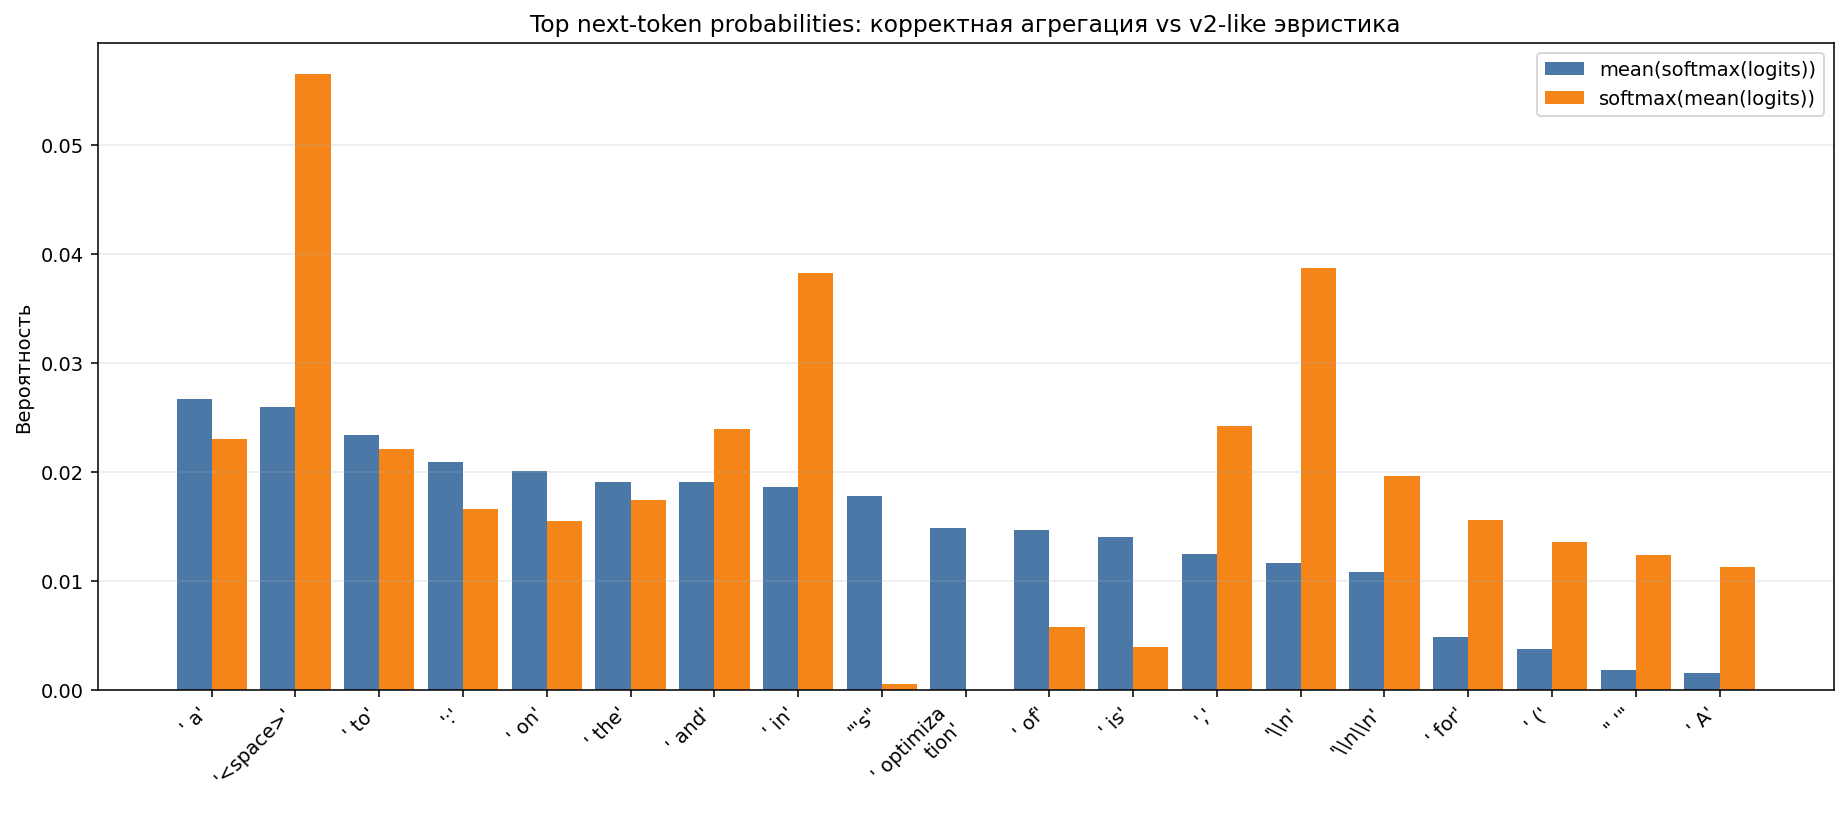

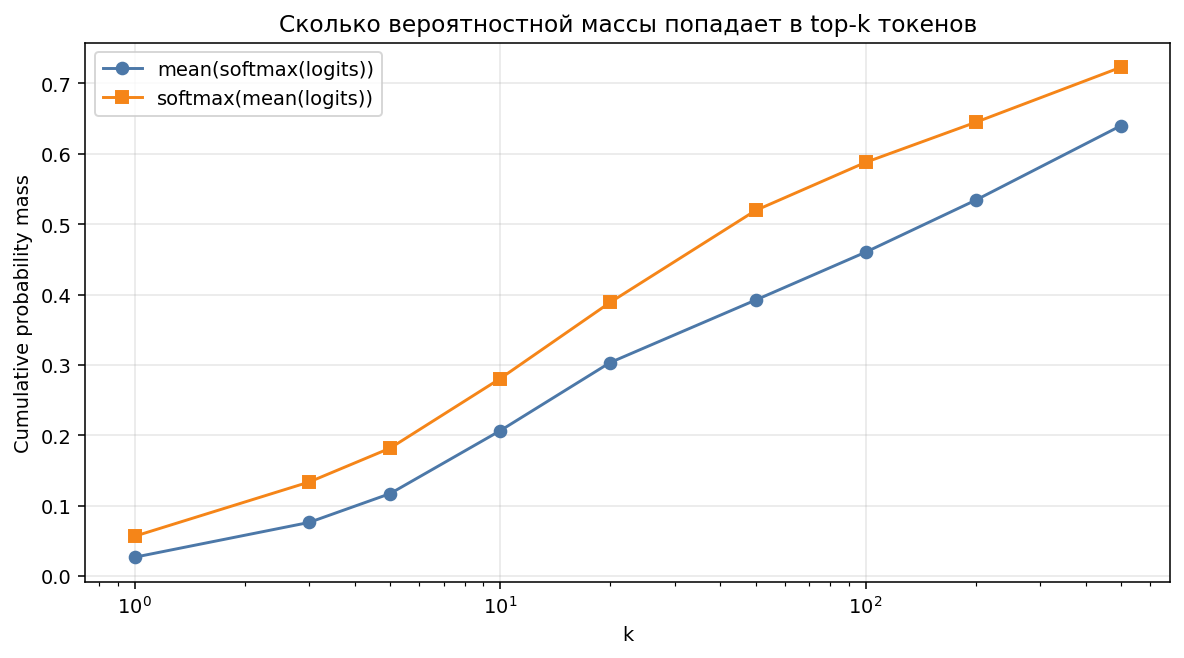

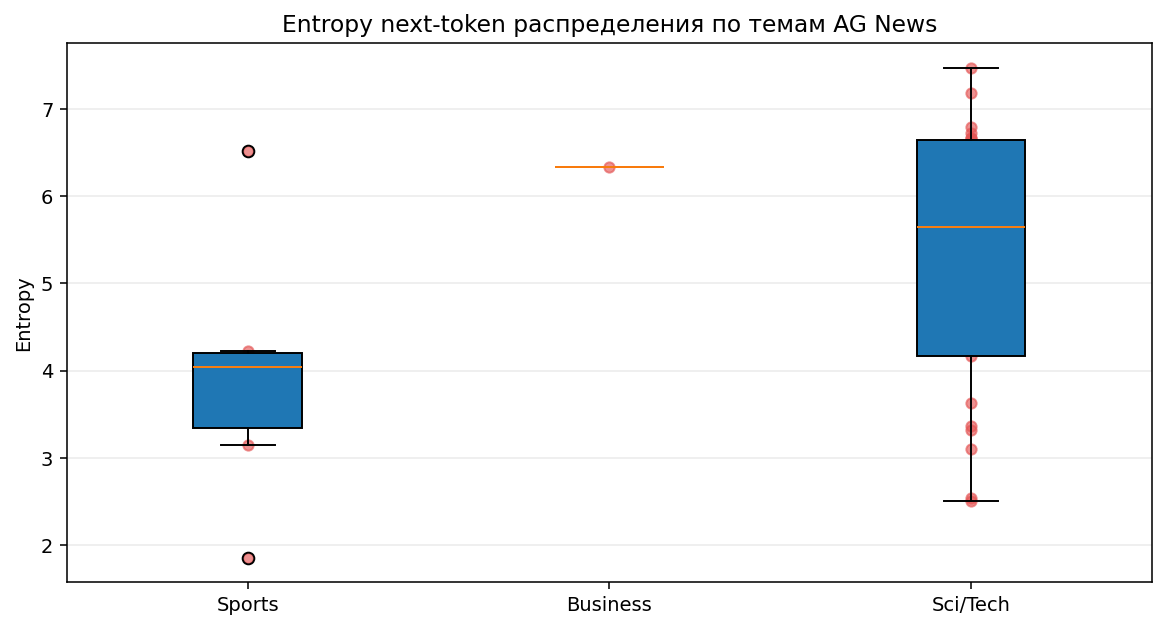

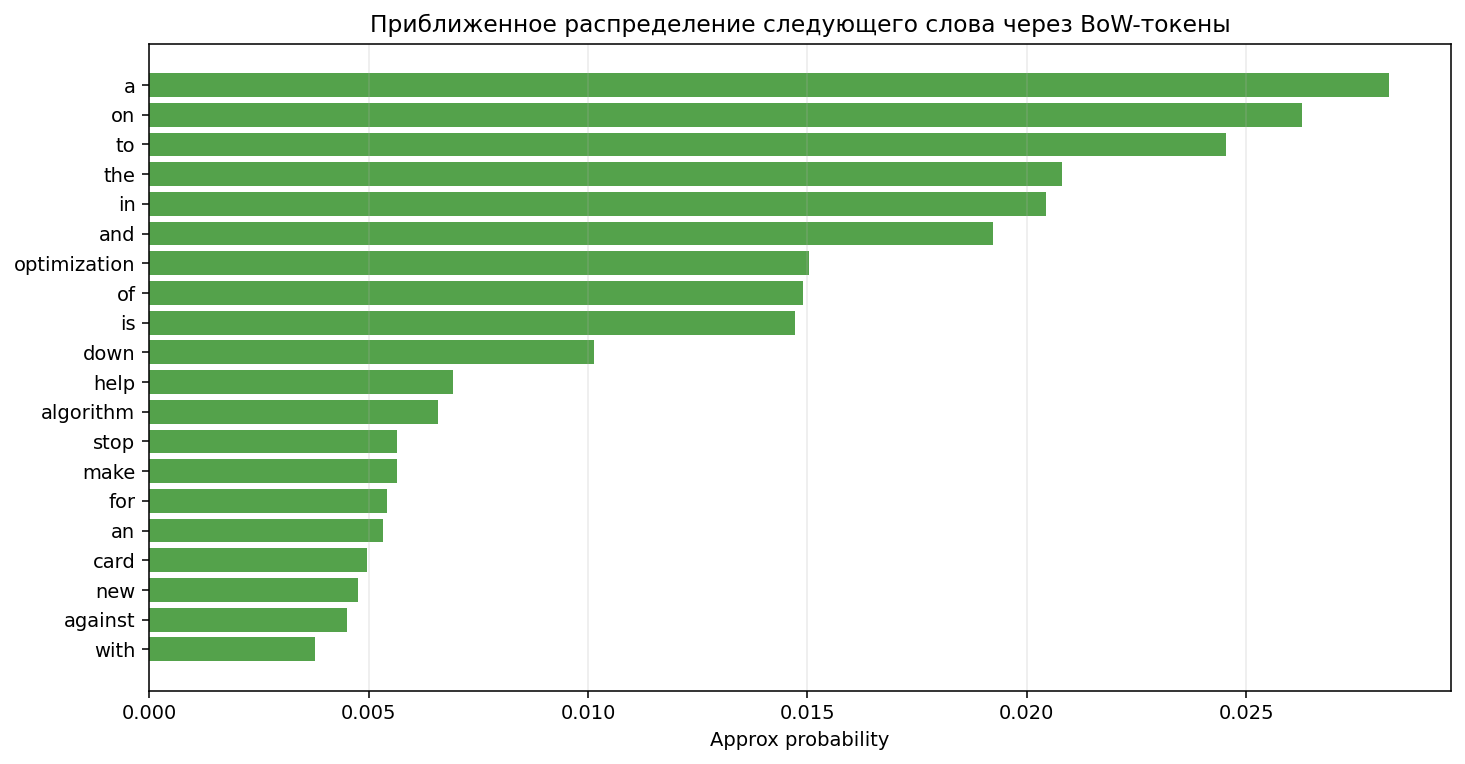

Графики сохранены:
- token_comparison: D:\HANDMADE_LLM\REPO\qwen\research\qwen_next_token_assets\01_token_distribution_comparison.png
- cumulative_mass: D:\HANDMADE_LLM\REPO\qwen\research\qwen_next_token_assets\02_cumulative_topk_mass.png
- entropy_by_label: D:\HANDMADE_LLM\REPO\qwen\research\qwen_next_token_assets\03_entropy_by_label.png
- word_distribution: D:\HANDMADE_LLM\REPO\qwen\research\qwen_next_token_assets\04_next_word_distribution.png


In [6]:
def savefig(fig, filename: str) -> Path:
    path = ASSET_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path


def wrap_label(label: str, width: int = 12) -> str:
    return "\n".join(textwrap.wrap(label, width=width)) or label


def plot_token_comparison(mean_top: pd.DataFrame, v2_top: pd.DataFrame, mean_probs: torch.Tensor, v2_probs: torch.Tensor) -> Path:
    union_ids = list(dict.fromkeys(mean_top.head(15)["token_id"].tolist() + v2_top.head(15)["token_id"].tolist()))[:20]
    labels = [wrap_label(token_label(tokenizer, tid), 10) for tid in union_ids]
    x = np.arange(len(union_ids))
    y_mean = [float(mean_probs[tid]) for tid in union_ids]
    y_v2 = [float(v2_probs[tid]) for tid in union_ids]

    fig, ax = plt.subplots(figsize=(16, 6))
    width = 0.42
    ax.bar(x - width / 2, y_mean, width, label="mean(softmax(logits))", color="#4C78A8")
    ax.bar(x + width / 2, y_v2, width, label="softmax(mean(logits))", color="#F58518")
    ax.set_title("Top next-token probabilities: корректная агрегация vs v2-like эвристика")
    ax.set_ylabel("Вероятность")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    return savefig(fig, "01_token_distribution_comparison.png")


def plot_cumulative_mass(mean_probs: torch.Tensor, v2_probs: torch.Tensor) -> Path:
    ks = np.array([1, 3, 5, 10, 20, 50, 100, 200, 500])
    mean_sorted = torch.sort(mean_probs, descending=True).values
    v2_sorted = torch.sort(v2_probs, descending=True).values
    mean_mass = [float(mean_sorted[:k].sum()) for k in ks]
    v2_mass = [float(v2_sorted[:k].sum()) for k in ks]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ks, mean_mass, marker="o", label="mean(softmax(logits))", color="#4C78A8")
    ax.plot(ks, v2_mass, marker="s", label="softmax(mean(logits))", color="#F58518")
    ax.set_xscale("log")
    ax.set_title("Сколько вероятностной массы попадает в top-k токенов")
    ax.set_xlabel("k")
    ax.set_ylabel("Cumulative probability mass")
    ax.grid(alpha=0.3)
    ax.legend()
    return savefig(fig, "02_cumulative_topk_mass.png")


def plot_entropy_by_label(df: pd.DataFrame, entropy: torch.Tensor) -> Path:
    plot_df = df.copy()
    plot_df["entropy"] = entropy.numpy()
    labels = [LABEL_NAMES[k] for k in sorted(plot_df["label"].unique())]
    data = [plot_df.loc[plot_df["label_name"] == label, "entropy"].values for label in labels]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.boxplot(data, tick_labels=labels, patch_artist=True)
    ax.scatter(
        np.concatenate([np.full(len(vals), i + 1) for i, vals in enumerate(data)]),
        np.concatenate(data),
        alpha=0.65,
        color="#E45756",
        s=28,
    )
    ax.set_title("Entropy next-token распределения по темам AG News")
    ax.set_ylabel("Entropy")
    ax.grid(axis="y", alpha=0.25)
    return savefig(fig, "03_entropy_by_label.png")


def plot_word_distribution(word_table: pd.DataFrame) -> Path:
    fig, ax = plt.subplots(figsize=(12, 6))
    top = word_table.head(20).iloc[::-1]
    ax.barh(top["word"], top["approx_prob"], color="#54A24B")
    ax.set_title("Приближенное распределение следующего слова через BoW-токены")
    ax.set_xlabel("Approx probability")
    ax.grid(axis="x", alpha=0.25)
    return savefig(fig, "04_next_word_distribution.png")


asset_paths = {
    "token_comparison": plot_token_comparison(mean_top, v2_top, mean_probs, softmax_mean_logits),
    "cumulative_mass": plot_cumulative_mass(mean_probs, softmax_mean_logits),
    "entropy_by_label": plot_entropy_by_label(df, entropy),
    "word_distribution": plot_word_distribution(word_table),
}

print("Графики сохранены:")
for name, path in asset_paths.items():
    print(f"- {name}: {path}")

## Модуль 5: итоговая интерпретация и Markdown-отчет

Финальная ячейка собирает ключевые метрики, печатает человекочитаемую интерпретацию и записывает отдельный Markdown-отчет с графиками.

In [7]:
def interpret_results() -> str:
    mean_top_token = mean_top.iloc[0]
    v2_top_token = v2_top.iloc[0]
    top_word = word_table.iloc[0]
    return (
        f"Эксперимент показывает, как Qwen3-4B распределяет вероятность следующего токена после коротких "
        f"новостных prefix prompts из AG News. Корректное корпусное распределение mean(softmax(logits)) имеет "
        f"entropy={mean_probs_entropy:.4f}, а v2-like softmax(mean(logits)) имеет entropy={v2_entropy:.4f}. "
        f"Jensen-Shannon divergence между ними равен {jsd:.6f}, top-20 overlap={top20_overlap}/20. "
        f"Главный токен по корректной агрегации: {mean_top_token['token']} с p={mean_top_token['mean_prob']:.4f}. "
        f"Главный токен по v2-like агрегации: {v2_top_token['token']} с p={v2_top_token['v2_like_prob']:.4f}. "
        f"Приближенно самое вероятное следующее слово: '{top_word['word']}' с p≈{top_word['approx_prob']:.4f}. "
        f"Практический вывод: если цель — оценить среднее поведение модели по корпусу, лучше усреднять уже "
        f"нормированные вероятности, а не logits. Softmax от средних logits может сделать распределение более "
        f"острым и сместить интерпретацию top tokens."
    )


interpretation = interpret_results()
print("Итоговая интерпретация")
print("---------------------")
print(textwrap.fill(interpretation, width=110))

report_path = RESEARCH_DIR / "qwen_next_token_word_distribution_report.md"

def rel(path: Path) -> str:
    return path.relative_to(RESEARCH_DIR).as_posix()

report = f"""# Qwen3-4B: распределение следующего токена и приближенного следующего слова

## Цель

Построить улучшенную версию экспериментов `qwen-distributions_v1.ipynb` и `qwen-distributions-v2.ipynb`: не просто вывести top tokens, а сравнить способы агрегации logits/probabilities, визуализировать распределения и дать приближенную word-level интерпретацию.

## Конфигурация

- Модель: `{MODEL_NAME}`
- Датасет: `{DATASET_NAME}`, split `{DATASET_SPLIT}`
- Количество примеров: `{len(df)}`
- Prefix words: `{PREFIX_WORDS}`
- Batch size: `{BATCH_SIZE}`
- Device: `{DEVICE}`
- Параметров модели: `{model_params_m:.1f}M`

## Основные метрики

- Средняя entropy по отдельным prompt: `{mean_sample_entropy:.4f}`
- Entropy `mean(softmax(logits))`: `{mean_probs_entropy:.4f}`
- Entropy `softmax(mean(logits))`: `{v2_entropy:.4f}`
- Jensen-Shannon divergence между агрегациями: `{jsd:.6f}`
- Top-20 overlap: `{top20_overlap}/20`
- Масса BoW word approximation: `{word_coverage:.4f}`

## Интерпретация

{interpretation}

## Top-10 токенов по корректной агрегации

{mean_top.head(10).to_markdown(index=False)}

## Top-10 приближенных следующих слов

{word_table.head(10).to_markdown(index=False)}

## Графики

### 1. Next-token distribution comparison

![Token distribution comparison]({rel(asset_paths['token_comparison'])})

Этот график сравнивает корректное корпусное распределение `mean(softmax(logits))` и старую эвристику `softmax(mean(logits))`. Если столбцы сильно расходятся, значит нельзя безоговорочно переносить выводы старого подхода на вероятностную интерпретацию.

### 2. Cumulative top-k mass

![Cumulative top-k mass]({rel(asset_paths['cumulative_mass'])})

График показывает, насколько распределение концентрируется в top-k токенах. Более крутая кривая означает более острую, менее энтропийную картину.

### 3. Entropy by AG News label

![Entropy by label]({rel(asset_paths['entropy_by_label'])})

Этот график показывает, насколько неопределенность next-token распределения меняется по темам. Для маленького среза это диагностический сигнал, а не статистически финальный вывод.

### 4. Approximate next-word distribution

![Next word distribution]({rel(asset_paths['word_distribution'])})

Это не полная word probability marginalization. Это BoW-аппроксимация по top word-start токенам. Она полезна как визуальный слой поверх token-level распределения.

## Ограничения

- Использован небольшой срез `{len(df)}` примеров, чтобы эксперимент можно было прогнать локально.
- Word-level распределение является приближением по BoW-токенам, а не полной Pimentel & Meister маргинализацией по всем субсловным путям.
- Для более строгих выводов нужно увеличить `MAX_SAMPLES`, прогнать несколько random seeds и отдельно сравнить разные домены.
"""

report_path.write_text(report, encoding="utf-8")
print(f"Markdown-отчет сохранен: {report_path}")

Итоговая интерпретация
---------------------
Эксперимент показывает, как Qwen3-4B распределяет вероятность следующего токена после коротких новостных
prefix prompts из AG News. Корректное корпусное распределение mean(softmax(logits)) имеет entropy=7.2851, а
v2-like softmax(mean(logits)) имеет entropy=6.6238. Jensen-Shannon divergence между ними равен 0.166515,
top-20 overlap=11/20. Главный токен по корректной агрегации: ' a' с p=0.0267. Главный токен по v2-like
агрегации: '<space>' с p=0.0566. Приближенно самое вероятное следующее слово: 'a' с p≈0.0283. Практический
вывод: если цель — оценить среднее поведение модели по корпусу, лучше усреднять уже нормированные вероятности,
а не logits. Softmax от средних logits может сделать распределение более острым и сместить интерпретацию top
tokens.
Markdown-отчет сохранен: D:\HANDMADE_LLM\REPO\qwen\research\qwen_next_token_word_distribution_report.md
